In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal

In [2]:
class QuarState(TypedDict): 
    a: float
    b: float
    c: float
    equation: str
    discriminant: float
    result: str
    

In [3]:
graph = StateGraph(QuarState)

In [4]:
def show_equation(state: QuarState) -> QuarState: 
    state['equation'] = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return state


def calculate_discriminant(state: QuarState) -> QuarState:
    a = state['a']
    b = state['b']
    c = state['c']
    D = b**2 - (4*a*c)
    state['discriminant'] = D
    return state

In [5]:
def real_roots(state: QuarState) -> QuarState: 
    a = state['a']
    b = state['b']
    c = state['c']
    D = state['discriminant']
    root1 = (-b + D**0.5) / (2*a) 
    root2 = (-b - D**0.5) / (2*a)
    state['result'] = f"Real roots: {root1}, {root2}"
    return state

def repeated_roots(state: QuarState) -> QuarState: 
    a = state['a']
    b = state['b']
    c = state['c']
    D = state['discriminant']
    root = -b / (2*a)
    state['result'] = f"Repeated root: {root}"
    return state


def complex_roots(state: QuarState) -> QuarState: 
    state['result'] = f"No real roots exist."
    return state

def check_condition(state: QuarState) -> Literal['real_roots', 'repeated_roots', 'complex_roots']:
    D = state['discriminant']
    if D > 0: 
        return 'real_roots'
    elif D == 0:
        return 'repeated_roots' 
    else:
        return 'complex_roots'

In [6]:
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('complex_roots', complex_roots)

In [7]:
graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('complex_roots', END)

workflow = graph.compile()

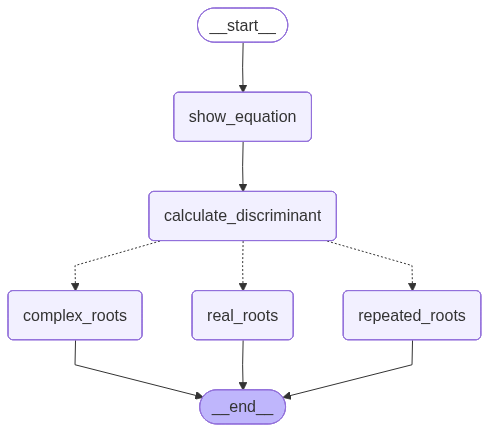

In [8]:
workflow

In [10]:
inital_state = {
    'a': 4, 
    'b': 2, 
    'c': 4
}

workflow.invoke(inital_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4x^2 + 2x + 4 = 0',
 'discriminant': -60,
 'result': 'No real roots exist.'}